In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:

from utils.enums import Ticker, TimeFrame
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.pyplot as plt
from utils.enums import Ticker
from feature_extraction.feature_extractor_class import FeatureExtractor
from eda.feature_explorer import FeatureExplorer
import pandas as pd


/home/raman/repos/Trading-Algo/utils/permutation_test/permute_bars.py:38: UserWarning: feature_selection.opt_thresh not found. Using simplified threshold optimization. For full functionality, ensure the opt_thresh module is available.
  warnings.warn(


In [3]:
old_feature = pd.read_csv('feature_export.csv')
new_feature = pd.read_csv('feature_data.csv')

In [4]:
old_feature 

,datetime,feature_name,raw_feature,binned_feature,binary_signal,ticker,raw_return,log_return,log_return_atr,log_return_ewsd,ticker.1
0,2000-01-04 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,0.000000,0,0,GC,-0.020035,-0.020238,-0.020238,-0.020238,GC
1,2000-01-05 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,50.000000,1,1,GC,-0.005640,-0.005656,-0.005656,-0.005656,GC
2,2000-01-06 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,50.000000,1,1,GC,0.002841,0.002837,0.002837,0.002837,GC
3,2000-01-07 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,74.719887,2,0,GC,0.001416,0.001415,0.001415,0.001415,GC
4,2000-01-10 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,99.440507,2,0,GC,0.001062,0.001062,0.001062,0.001062,GC
...,...,...,...,...,...,...,...,...,...,...,...
6282,2024-12-24 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,41.953985,1,1,GC,0.002320,0.002317,0.002317,0.002317,GC
6283,2024-12-26 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,40.683498,0,0,GC,0.006027,0.006009,0.006009,0.006009,GC
6284,2024-12-27 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,53.624896,1,1,GC,-0.008215,-0.008249,-0.008249,-0.008249,GC
6285,2024-12-30 00:00:00+00:00,cumulativeRsi_signal_D_avgPeriod_2_lookback_3,51.085083,1,1,GC,-0.006828,-0.006852,-0.006852,-0.006852,GC


In [5]:
# Example 1: Using bias_node_specs (recommended for feature extraction)
bias_node_specs_ts = [
    {
        'module_name': 'ts_feature',
        'timeframes': [TimeFrame.D],
        'params': {
            'wrapped_module': 'rsi',
            'wrapped_params': {'lookback': 2},  # RSI lookback period
            'lookback': 5,  # Time series feature lookback window
            'transformation': 'count_below_mean',  # From utils.functime
            'transformation_name': 'countBelowMean'
        }
    }
]

In [6]:
# Compare old_feature and new_feature DataFrames
import numpy as np

print("="*80)
print("COMPARISON ANALYSIS: Old Model vs New Model")
print("="*80)

# Basic info
print(f"\n1. BASIC INFO:")
print(f"   Old model rows: {len(old_feature):,}")
print(f"   New model rows: {len(new_feature):,}")
print(f"   Difference: {len(new_feature) - len(old_feature):,} rows")

print(f"\n   Old model columns: {list(old_feature.columns)}")
print(f"   New model columns: {list(new_feature.columns)}")

# Clean up duplicate ticker column in old_feature if it exists
if 'ticker.1' in old_feature.columns:
    old_feature = old_feature.drop(columns=['ticker.1'])
    print(f"\n   Removed duplicate 'ticker.1' column from old_feature")

# Normalize feature names for comparison
old_feature['feature_name_normalized'] = old_feature['feature_name'].str.replace('cumulativeRsi', 'cumulative_rsi', regex=False)
new_feature['feature_name_normalized'] = new_feature['feature_name'].copy()

# Convert datetime to ensure matching
old_feature['datetime'] = pd.to_datetime(old_feature['datetime'])
new_feature['datetime'] = pd.to_datetime(new_feature['datetime'])

# Create merge keys
old_feature['merge_key'] = old_feature['datetime'].astype(str) + '_' + old_feature['feature_name_normalized']
new_feature['merge_key'] = new_feature['datetime'].astype(str) + '_' + new_feature['feature_name_normalized']

print(f"\n2. ROW OVERLAP:")
old_keys = set(old_feature['merge_key'])
new_keys = set(new_feature['merge_key'])
common_keys = old_keys & new_keys
only_old = old_keys - new_keys
only_new = new_keys - old_keys

print(f"   Common rows: {len(common_keys):,}")
print(f"   Only in old: {len(only_old):,}")
print(f"   Only in new: {len(only_new):,}")

# Merge on common keys for comparison
merged = old_feature.merge(
    new_feature,
    on='merge_key',
    suffixes=('_old', '_new'),
    how='outer',
    indicator=True
)

print(f"\n3. COLUMN-BY-COLUMN COMPARISON:")
print("="*80)

# Columns to compare (excluding merge keys and normalized names)
compare_cols = ['raw_feature', 'binned_feature', 'binary_signal', 
                'raw_return', 'log_return', 'log_return_atr', 'log_return_ewsd']

# Only compare rows that exist in both
common_rows = merged[merged['_merge'] == 'both'].copy()

if len(common_rows) > 0:
    print(f"\n   Comparing {len(common_rows):,} common rows...\n")
    
    for col in compare_cols:
        old_col = f"{col}_old"
        new_col = f"{col}_new"
        
        if old_col in common_rows.columns and new_col in common_rows.columns:
            # Get numeric columns
            old_vals = pd.to_numeric(common_rows[old_col], errors='coerce')
            new_vals = pd.to_numeric(common_rows[new_col], errors='coerce')
            
            # Count differences
            if col in ['binned_feature', 'binary_signal']:
                # For integer columns, exact match
                diff_mask = old_vals != new_vals
                n_diff = diff_mask.sum()
                pct_diff = (n_diff / len(common_rows)) * 100
                
                print(f"   {col}:")
                print(f"      Differences: {n_diff:,} ({pct_diff:.2f}%)")
                
                if n_diff > 0:
                    diff_df = common_rows[diff_mask][['datetime_old', 'feature_name_old', old_col, new_col]].head(10)
                    print(f"      Sample differences (first 10):")
                    for idx, row in diff_df.iterrows():
                        print(f"        {row['datetime_old']} | {row['feature_name_old']}: {row[old_col]} -> {row[new_col]}")
                    if n_diff > 10:
                        print(f"        ... and {n_diff - 10} more")
            else:
                # For float columns, check for significant differences
                diff_mask = ~np.isclose(old_vals, new_vals, equal_nan=True, rtol=1e-5)
                n_diff = diff_mask.sum()
                pct_diff = (n_diff / len(common_rows)) * 100
                
                # Calculate statistics
                abs_diff = np.abs(old_vals - new_vals)
                mean_diff = abs_diff.mean()
                max_diff = abs_diff.max()
                
                print(f"   {col}:")
                print(f"      Differences: {n_diff:,} ({pct_diff:.2f}%)")
                print(f"      Mean absolute diff: {mean_diff:.6f}")
                print(f"      Max absolute diff: {max_diff:.6f}")
                
                if n_diff > 0:
                    # Show rows with largest differences
                    diff_df = common_rows[diff_mask].copy()
                    diff_df['abs_diff'] = abs_diff[diff_mask]
                    diff_df = diff_df.nlargest(5, 'abs_diff')[['datetime_old', 'feature_name_old', old_col, new_col, 'abs_diff']]
                    print(f"      Top 5 largest differences:")
                    for idx, row in diff_df.iterrows():
                        print(f"        {row['datetime_old']} | {row['feature_name_old']}: {row[old_col]:.6f} vs {row[new_col]:.6f} (diff: {row['abs_diff']:.6f})")
        else:
            print(f"   {col}: Column not found in both DataFrames")
else:
    print("\n   No common rows to compare!")

print(f"\n4. UNIQUE ROWS ANALYSIS:")
print("="*80)

if len(only_old) > 0:
    only_old_df = old_feature[old_feature['merge_key'].isin(only_old)]
    print(f"\n   Rows only in old model ({len(only_old_df):,}):")
    print(f"      Date range: {only_old_df['datetime'].min()} to {only_old_df['datetime'].max()}")
    print(f"      Features: {only_old_df['feature_name'].unique().tolist()}")
    print(f"      Sample (first 5):")
    print(only_old_df[['datetime', 'feature_name', 'raw_feature', 'binned_feature', 'binary_signal']].head())

if len(only_new) > 0:
    only_new_df = new_feature[new_feature['merge_key'].isin(only_new)]
    print(f"\n   Rows only in new model ({len(only_new_df):,}):")
    print(f"      Date range: {only_new_df['datetime'].min()} to {only_new_df['datetime'].max()}")
    print(f"      Features: {only_new_df['feature_name'].unique().tolist()}")
    print(f"      Sample (first 5):")
    print(only_new_df[['datetime', 'feature_name', 'raw_feature', 'binned_feature', 'binary_signal']].head())

print(f"\n5. SUMMARY STATISTICS:")
print("="*80)

# Compare key metrics
if len(common_rows) > 0:
    print(f"\n   Binary Signal Agreement:")
    signal_agreement = (common_rows['binary_signal_old'] == common_rows['binary_signal_new']).sum()
    signal_total = len(common_rows)
    print(f"      Agreement: {signal_agreement:,} / {signal_total:,} ({signal_agreement/signal_total*100:.2f}%)")
    
    print(f"\n   Binned Feature Agreement:")
    bin_agreement = (common_rows['binned_feature_old'] == common_rows['binned_feature_new']).sum()
    print(f"      Agreement: {bin_agreement:,} / {signal_total:,} ({bin_agreement/signal_total*100:.2f}%)")

print("\n" + "="*80)
print("COMPARISON COMPLETE")
print("="*80)

COMPARISON ANALYSIS: Old Model vs New Model

1. BASIC INFO:
   Old model rows: 6,287
   New model rows: 12,572
   Difference: 6,285 rows

   Old model columns: ['datetime', 'feature_name', 'raw_feature', 'binned_feature', 'binary_signal', 'ticker', 'raw_return', 'log_return', 'log_return_atr', 'log_return_ewsd', 'ticker.1']
   New model columns: ['datetime', 'feature_name', 'raw_feature', 'binned_feature', 'binary_signal', 'ticker', 'raw_return', 'log_return', 'log_return_atr', 'log_return_ewsd']

   Removed duplicate 'ticker.1' column from old_feature

2. ROW OVERLAP:
   Common rows: 6,286
   Only in old: 1
   Only in new: 6,286

3. COLUMN-BY-COLUMN COMPARISON:

   Comparing 6,286 common rows...

   raw_feature:
      Differences: 6,284 (99.97%)
      Mean absolute diff: 10.348476
      Max absolute diff: 50.000000
      Top 5 largest differences:
        2000-01-04 00:00:00+00:00 | cumulativeRsi_signal_D_avgPeriod_2_lookback_3: 0.000000 vs 50.000000 (diff: 50.000000)
        2008-03-

In [7]:
# Automated column-by-column comparison (loops over all columns)
print("\n" + "="*80)
print("AUTOMATED COLUMN COMPARISON")
print("="*80)

# Clean and prepare data
old_clean = old_feature.copy()
new_clean = new_feature.copy()

# Remove duplicate ticker column if exists
if 'ticker.1' in old_clean.columns:
    old_clean = old_clean.drop(columns=['ticker.1'])

# Normalize feature names
old_clean['feature_name_norm'] = old_clean['feature_name'].str.replace('cumulativeRsi', 'cumulative_rsi', regex=False)
new_clean['feature_name_norm'] = new_clean['feature_name'].copy()

# Ensure datetime is datetime type
old_clean['datetime'] = pd.to_datetime(old_clean['datetime'])
new_clean['datetime'] = pd.to_datetime(new_feature['datetime'])

# Create merge key
old_clean['key'] = old_clean['datetime'].astype(str) + '_' + old_clean['feature_name_norm']
new_clean['key'] = new_clean['datetime'].astype(str) + '_' + new_clean['feature_name_norm']

# Merge
merged_all = old_clean.merge(
    new_clean,
    on='key',
    suffixes=('_old', '_new'),
    how='inner'  # Only compare rows that exist in both
)

print(f"\nComparing {len(merged_all):,} common rows across all columns...\n")

# Get all columns to compare (exclude merge keys and normalized columns)
exclude_cols = ['key', 'feature_name_norm', 'feature_name_old', 'feature_name_new', 
                'datetime_old', 'datetime_new', 'ticker_old', 'ticker_new']

# Find columns that exist in both
old_cols = [c for c in old_clean.columns if c not in ['key', 'feature_name_norm', 'datetime', 'feature_name']]
new_cols = [c for c in new_clean.columns if c not in ['key', 'feature_name_norm', 'datetime', 'feature_name']]

# Compare each column
comparison_results = []

for col in old_cols:
    if col in new_cols:
        old_col_name = f"{col}_old" if f"{col}_old" in merged_all.columns else col
        new_col_name = f"{col}_new" if f"{col}_new" in merged_all.columns else col
        
        if old_col_name in merged_all.columns and new_col_name in merged_all.columns:
            old_vals = pd.to_numeric(merged_all[old_col_name], errors='coerce')
            new_vals = pd.to_numeric(merged_all[new_col_name], errors='coerce')
            
            # Check for differences
            if col in ['binned_feature', 'binary_signal']:
                # Integer comparison
                diff_mask = old_vals != new_vals
                n_diff = diff_mask.sum()
            else:
                # Float comparison with tolerance
                diff_mask = ~np.isclose(old_vals, new_vals, equal_nan=True, rtol=1e-5, atol=1e-8)
                n_diff = diff_mask.sum()
            
            pct_diff = (n_diff / len(merged_all)) * 100 if len(merged_all) > 0 else 0
            
            # Calculate statistics for numeric columns
            if pd.api.types.is_numeric_dtype(old_vals) and pd.api.types.is_numeric_dtype(new_vals):
                abs_diff = np.abs(old_vals - new_vals)
                mean_abs_diff = abs_diff.mean()
                max_abs_diff = abs_diff.max()
                mean_old = old_vals.mean()
                mean_new = new_vals.mean()
            else:
                mean_abs_diff = None
                max_abs_diff = None
                mean_old = None
                mean_new = None
            
            comparison_results.append({
                'column': col,
                'n_differences': n_diff,
                'pct_different': pct_diff,
                'mean_abs_diff': mean_abs_diff,
                'max_abs_diff': max_abs_diff,
                'mean_old': mean_old,
                'mean_new': mean_new,
                'n_total': len(merged_all)
            })

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('n_differences', ascending=False)

print("COMPARISON SUMMARY:")
print("="*80)
print(comparison_df.to_string(index=False))

# Show detailed differences for columns with most discrepancies
print("\n\nDETAILED ANALYSIS FOR TOP DIFFERENT COLUMNS:")
print("="*80)

top_diff_cols = comparison_df.head(5)['column'].tolist()

for col in top_diff_cols:
    old_col_name = f"{col}_old" if f"{col}_old" in merged_all.columns else col
    new_col_name = f"{col}_new" if f"{col}_new" in merged_all.columns else col
    
    if old_col_name in merged_all.columns and new_col_name in merged_all.columns:
        old_vals = pd.to_numeric(merged_all[old_col_name], errors='coerce')
        new_vals = pd.to_numeric(merged_all[new_col_name], errors='coerce')
        
        if col in ['binned_feature', 'binary_signal']:
            diff_mask = old_vals != new_vals
        else:
            diff_mask = ~np.isclose(old_vals, new_vals, equal_nan=True, rtol=1e-5, atol=1e-8)
        
        if diff_mask.sum() > 0:
            diff_sample = merged_all[diff_mask][['datetime_old', 'feature_name_old', old_col_name, new_col_name]].head(10)
            print(f"\n{col} - Sample differences (first 10 of {diff_mask.sum()}):")
            print(diff_sample.to_string(index=False))


AUTOMATED COLUMN COMPARISON

Comparing 6,286 common rows across all columns...

COMPARISON SUMMARY:
                 column  n_differences  pct_different  mean_abs_diff  max_abs_diff  mean_old  mean_new  n_total
            raw_feature           6284      99.968183      10.348476     50.000000 52.985574 52.991068     6286
        log_return_ewsd           6283      99.952275       1.071953     17.642080  0.000018  0.054831     6286
         log_return_atr           6283      99.952275       0.063996      2.165936  0.000018  0.004213     6286
             log_return           6282      99.936367       0.011185      0.104406  0.000018  0.000355     6286
             raw_return           6282      99.936367       0.011181      0.106912  0.000070  0.000414     6286
         binned_feature           4355      69.280942       1.066656      3.000000  1.000477  2.000318     6286
          binary_signal           2166      34.457525       0.344575      1.000000  0.333280  0.199968     6286
   

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (5,).

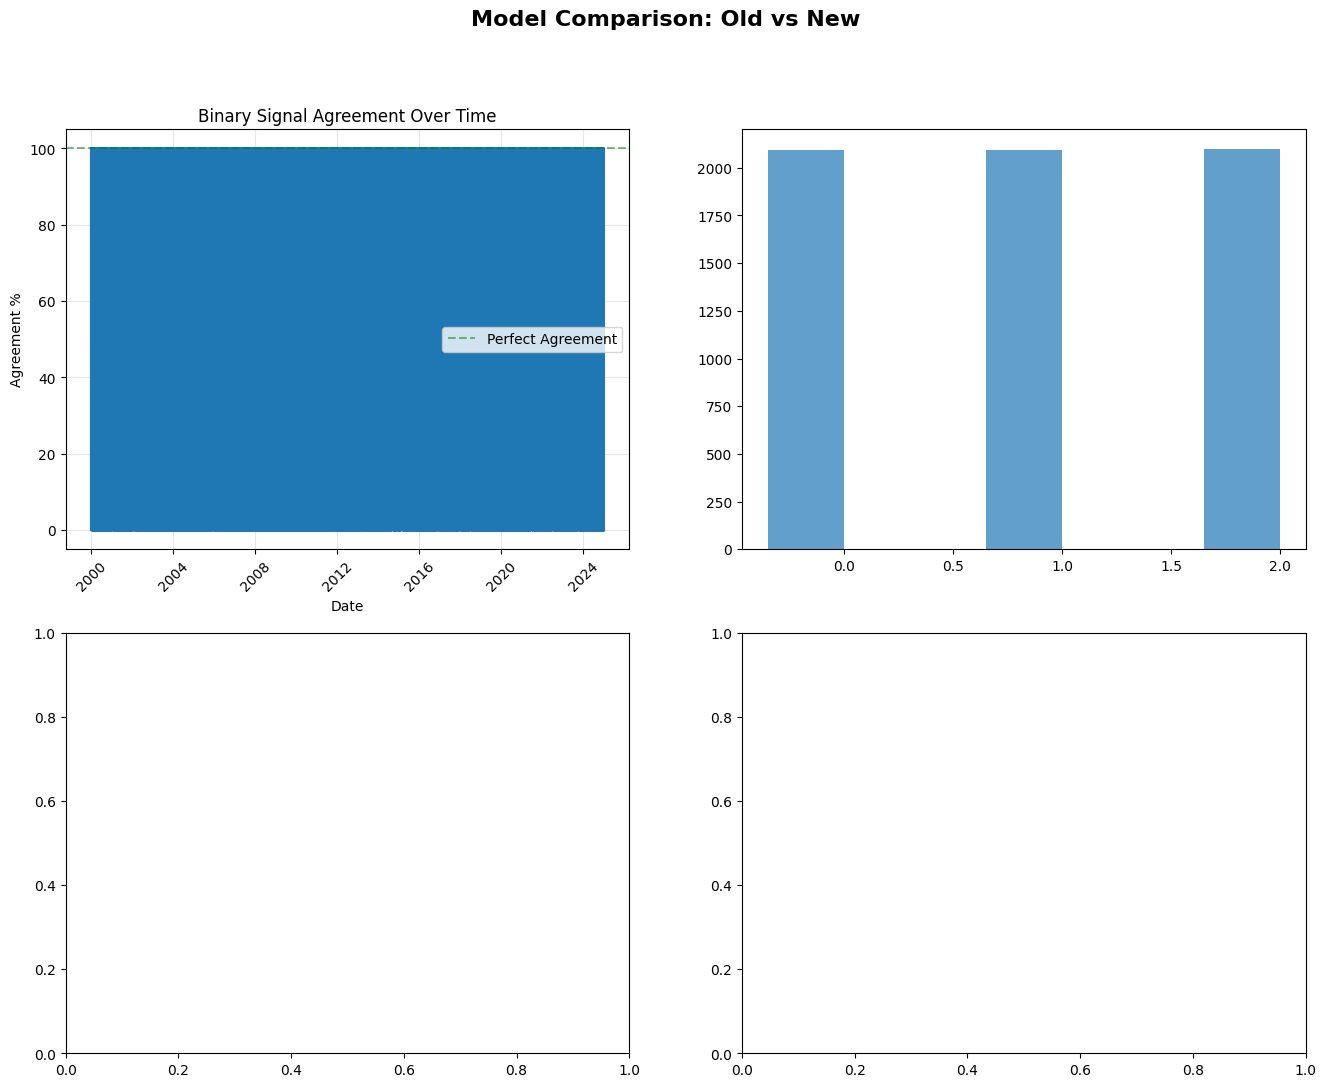

In [8]:
# Visualize differences
import matplotlib.pyplot as plt

# Set up the comparison data if not already done
if 'merged_all' not in locals():
    # Re-run the merge from previous cell
    old_clean = old_feature.copy()
    new_clean = new_feature.copy()
    if 'ticker.1' in old_clean.columns:
        old_clean = old_clean.drop(columns=['ticker.1'])
    old_clean['feature_name_norm'] = old_clean['feature_name'].str.replace('cumulativeRsi', 'cumulative_rsi', regex=False)
    new_clean['feature_name_norm'] = new_feature['feature_name'].copy()
    old_clean['datetime'] = pd.to_datetime(old_clean['datetime'])
    new_clean['datetime'] = pd.to_datetime(new_feature['datetime'])
    old_clean['key'] = old_clean['datetime'].astype(str) + '_' + old_clean['feature_name_norm']
    new_clean['key'] = new_clean['datetime'].astype(str) + '_' + new_clean['feature_name_norm']
    merged_all = old_clean.merge(new_clean, on='key', suffixes=('_old', '_new'), how='inner')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison: Old vs New', fontsize=16, fontweight='bold')

# 1. Binary Signal Agreement Over Time
ax1 = axes[0, 0]
merged_all['datetime'] = pd.to_datetime(merged_all['datetime_old'])
merged_all['signal_match'] = (merged_all['binary_signal_old'] == merged_all['binary_signal_new']).astype(int)
signal_agreement_by_date = merged_all.groupby(merged_all['datetime'].dt.date)['signal_match'].mean()
ax1.plot(signal_agreement_by_date.index, signal_agreement_by_date.values * 100, linewidth=2)
ax1.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Perfect Agreement')
ax1.set_xlabel('Date')
ax1.set_ylabel('Agreement %')
ax1.set_title('Binary Signal Agreement Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Binned Feature Distribution Comparison
ax2 = axes[0, 1]
if 'binned_feature_old' in merged_all.columns and 'binned_feature_new' in merged_all.columns:
    old_bins = merged_all['binned_feature_old'].value_counts().sort_index()
    new_bins = merged_all['binned_feature_new'].value_counts().sort_index()
    x = np.arange(len(old_bins))
    width = 0.35
    ax2.bar(x - width/2, old_bins.values, width, label='Old Model', alpha=0.7)
    ax2.bar(x + width/2, new_bins.values, width, label='New Model', alpha=0.7)
    ax2.set_xlabel('Bin Number')
    ax2.set_ylabel('Count')
    ax2.set_title('Binned Feature Distribution')
    ax2.set_xticks(x)
    ax2.set_xticklabels(old_bins.index)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

# 3. Return Values Scatter Plot
ax3 = axes[1, 0]
if 'log_return_old' in merged_all.columns and 'log_return_new' in merged_all.columns:
    old_ret = pd.to_numeric(merged_all['log_return_old'], errors='coerce')
    new_ret = pd.to_numeric(merged_all['log_return_new'], errors='coerce')
    ax3.scatter(old_ret, new_ret, alpha=0.3, s=10)
    # Add diagonal line
    min_val = min(old_ret.min(), new_ret.min())
    max_val = max(old_ret.max(), new_ret.max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Match')
    ax3.set_xlabel('Old Model log_return')
    ax3.set_ylabel('New Model log_return')
    ax3.set_title('Return Values Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Difference Distribution
ax4 = axes[1, 1]
if 'log_return_old' in merged_all.columns and 'log_return_new' in merged_all.columns:
    old_ret = pd.to_numeric(merged_all['log_return_old'], errors='coerce')
    new_ret = pd.to_numeric(merged_all['log_return_new'], errors='coerce')
    diff = old_ret - new_ret
    ax4.hist(diff.dropna(), bins=50, alpha=0.7, edgecolor='black')
    ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Difference')
    ax4.set_xlabel('Difference (Old - New)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Distribution of Return Differences')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Additional: Show correlation matrix for numeric columns
print("\nCORRELATION BETWEEN OLD AND NEW MODEL VALUES:")
print("="*80)
numeric_cols = ['raw_feature', 'binned_feature', 'binary_signal', 
                'raw_return', 'log_return', 'log_return_atr', 'log_return_ewsd']

correlations = []
for col in numeric_cols:
    old_col = f"{col}_old" if f"{col}_old" in merged_all.columns else None
    new_col = f"{col}_new" if f"{col}_new" in merged_all.columns else None
    
    if old_col and new_col:
        old_vals = pd.to_numeric(merged_all[old_col], errors='coerce')
        new_vals = pd.to_numeric(merged_all[new_col], errors='coerce')
        corr = old_vals.corr(new_vals)
        correlations.append({'column': col, 'correlation': corr})

corr_df = pd.DataFrame(correlations)
print(corr_df.to_string(index=False))

In [ ]:


# Step 1: Extract features using FeatureExtractor
extractor = FeatureExtractor(
    tickers=[
        Ticker.GC
        # Add more tickers as needed...
    ],
    start=datetime(2000, 1, 1),
    end=datetime(2024, 12, 31)
)

bias_node_specs = []

windows = range(2,5,1)
avg_windows = range(2,5,1)


for lookback in windows:
    for avg_period in avg_windows:
        bias_node_specs.append({
            'module_name': 'cumulative_rsi',
            'params': {
                'lookback': lookback,
                'avg_period': avg_period
            }
        })


roc_windows = [2,5,10,20,40,60,80, 100, 120, 140, 160, 180, 200, 252]
# for window in roc_windows:
    # bias_node_specs.append({
    #     'module_name': 'roc',
    #     'params': {
    #         'lookback': window,
    #         'normalize_by_ewsd': True,
    #     }
    
    # bias_node_specs.append({
    #     'module_name': 'rsi',
    #     'params': {
    #         'lookback': window,
    #     }
    # })


# ewmac = [(16,64), (32,128), (64,256)]
# for spanFast, spanSlow in ewmac:
#     bias_node_specs.append({
#         'module_name': 'ewmac',
#         'params': {
#             'spanFast': spanFast,
#             'spanSlow': spanSlow
#         }
#     })

# Extract features
result = extractor.extract(
    bias_node_specs=bias_node_specs
)

features = result['features']              # Clean features only
normalization = result['normalization']    # ATR/EWSD columns
targets = result['targets']    

# Step 2: Create FeatureExplorer from extracted dataframes
explorer = FeatureExplorer(
    features_df=features,
    targets_df=targets, 
    metadata=result
)




In [ ]:
# Use custom model and metric
from feature_selection.base_models import QuantileBinningModel
from feature_selection.base_models import DecisionTreeBinningModel
from utils.objective_metric import SortinoRatio

model = QuantileBinningModel(n_bins=5, selection_metric='sortino')
metric = SortinoRatio(annualization_factor=252)
decision_tree_model = DecisionTreeBinningModel(n_bins=4, selection_metric='sortino')



In [ ]:
features.columns

In [ ]:

# Step 3: Analyze (same API as before!)
# Plot deciles with log_return
figs = explorer.plot_all_deciles(n_bins=5, target_col='log_return')
plt.show()

# figures = explorer.plot_all_uniform_bins(
#     n_bins=10,
#     target_col='log_return',
# )
# plt.show()

# # # Plot 2-bin for each feature
# for feature_name in explorer.feature_names:
#     explorer.plot_2bin(feature_name, target_col='log_return')
# plt.show()

In [ ]:
from feature_selection.base_models.quantile_binning import QuantileBinningModel

model = QuantileBinningModel(n_bins=3, selection_metric='sortino')
export_df = explorer.export_feature_data(
    base_model=model,
    features=['cumulativeRsi_signal_D_avgPeriod_2_lookback_3'],
    target_col='log_return',
    strategy='long'
)
export_df.to_csv('feature_export.csv', index=False)

In [ ]:

# 1. Feature-Target correlations (Spearman - captures monotonic relationships)
fig1 = explorer.plot_feature_target_correlations(
    target_col='log_return',
    figsize=(10, 8),
    annot=True  # Show correlation values
)
plt.show()

# 2. Intra-Feature correlations (Pearson - linear relationships)
fig2 = explorer.plot_feature_correlations(
    figsize=(12, 10),
    annot=True, 
    mask_diagonal=True  
)
plt.show()

In [ ]:
explorer.plot_distributions(bins=50)
plt.show()

explorer.plot_timeseries(rolling_window=50)
plt.show()

In [ ]:

results = explorer.run_permutation_test(
    target_col='log_return',
    base_model=model,
    metric=metric,
    nreps=200
)

In [ ]:
figs, summary = explorer.plot_signal_cumsum(
    target_col='log_return',
    base_model=model,
    show_plot=True,
    metric=metric

)

In [ ]:
df, fig = explorer.plot_parameter_sensitivity(
    module_name='rsi',
    param_name='lookback',
    feature_name='signal',
    target_col='log_return', 
    base_model=model,
    custom_metric=metric
)


In [ ]:
# New 2D parameter sensitivity with 3D surface plot
df_2d, fig_2d = explorer.plot_2d_parameter_surface(
    module_name='ewmac',
    param1_name='spanFast',
    param2_name='spanSlow',
    feature_name='signal',
    target_col='log_return', 
    base_model=model,
    custom_metric=metric
)